# Gradiente de concentración en una partícula catalítica


Cuando una reacción ocurre en una partícula porosa, la concentración del reactivo puede ser menor en el interior que en la superficie. El perfil depende de la cinética, de la difusión interna y de la transferencia externa desde el fluido.

El ejemplo usa un modelo esférico de primer orden. La gráfica compara varios escenarios para ver cuándo domina cada resistencia.


Resumen de escenarios
Transferencia rapida: phi=0.40, eta=0.99, C_surface/C_bulk=1.00
Difusion interna baja: phi=0.90, eta=0.95, C_surface/C_bulk=1.00
Pelicula externa lenta: phi=0.40, eta=0.99, C_surface/C_bulk=0.98
Cinetica rapida: phi=0.76, eta=0.96, C_surface/C_bulk=0.99


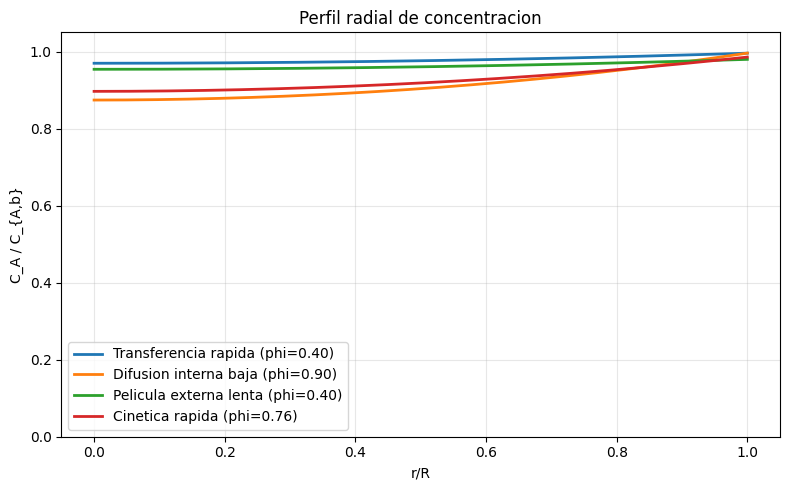

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Editable parameters
R_particle = 1.5e-3   # m
C_bulk = 1.0          # mol/L, used as reference
scenarios = [('Transferencia rapida', 0.03, 3.5e-06, 0.25), ('Difusion interna baja', 0.03, 7e-07, 0.25), ('Pelicula externa lenta', 0.006, 3.5e-06, 0.25), ('Cinetica rapida', 0.03, 3.5e-06, 0.9)]


def effectiveness_factor(phi):
    if phi < 1e-6:
        return 1.0
    return 3 / phi**2 * (phi / np.tanh(phi) - 1)


def profile(r_over_R, kf, De, k):
    phi = R_particle * np.sqrt(k / De)
    eta = effectiveness_factor(phi)
    C_surface = C_bulk / (1 + eta * k * R_particle / (3 * kf))
    r = np.maximum(r_over_R, 1e-6)
    internal = np.sinh(phi * r) / (r * np.sinh(phi)) if phi > 1e-6 else np.ones_like(r)
    internal[0] = phi / np.sinh(phi) if phi > 1e-6 else 1.0
    return C_surface * internal / C_bulk, phi, eta, C_surface / C_bulk

r = np.linspace(0, 1, 250)
plt.figure(figsize=(8, 5))
print("Resumen de escenarios")
for name, kf, De, k in scenarios:
    C, phi, eta, Cs = profile(r, kf, De, k)
    plt.plot(r, C, linewidth=2, label=f"{name} (phi={phi:.2f})")
    print(f"{name}: phi={phi:.2f}, eta={eta:.2f}, C_surface/C_bulk={Cs:.2f}")

plt.xlabel("r/R")
plt.ylabel("C_A / C_{A,b}")
plt.title("Perfil radial de concentracion")
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## Interpretación

Si la difusión interna es lenta o la cinética es rápida, aparece un gradiente acusado dentro de la partícula. Si la transferencia externa es lenta, incluso la concentración en la superficie cae respecto al volumen del fluido.
